# Load Libraries

In [1]:
# usuals
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split

# Load Dataset

In [9]:
df = pd.read_csv("online_shoppers_intention.csv")
display(df.head())
display(df.shape)
df.columns

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


(12330, 18)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

# EDA

Text(0.5, 1.0, 'Revenue Distribution')

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

Revenue
False    10422
True      1908
Name: count, dtype: int64

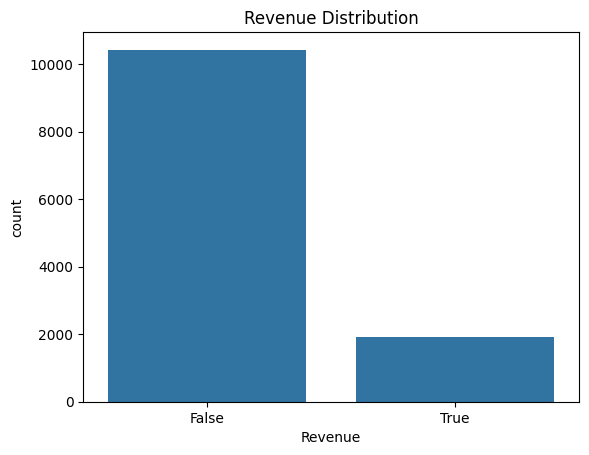

In [18]:
# Target balance
sns.countplot(x="Revenue", data=df)
display(plt.title("Revenue Distribution"))
display(df['Revenue'].value_counts(normalize=True) * 100)

# raw count
df["Revenue"].value_counts()

### Revenue Distribution:
- Class balance
    - 10,422 (84.5%) vs 1,908 (15.5%)
- Metric choice
    - Accuracy could mislead due to imbalance. Model predicting mostly "False" could appear 'good'.
    - Other metrics like F1, recall, PR AUC would suffice
##### Pre-processing decisions
- Stratified train/validate/test split to keep proportions similar across splits.

  Month  count      mean  conversion_pct
2   Feb    184  0.016304        1.630435
5   Mar   1907  0.100682       10.068170
6   May   3364  0.108502       10.850178
4  June    288  0.100694       10.069444
3   Jul    432  0.152778       15.277778
0   Aug    433  0.175520       17.551963
9   Sep    448  0.191964       19.196429
8   Oct    549  0.209472       20.947177
7   Nov   2998  0.253502       25.350233
1   Dec   1727  0.125072       12.507238


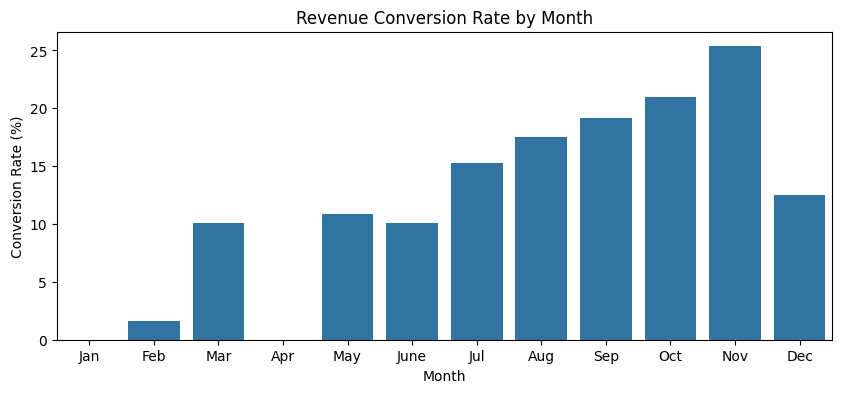

In [ ]:
# seasonality trends
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_conv = (
    df.groupby('Month')['Revenue']
      .agg(['count', 'mean'])
      .reset_index()
)

month_conv['Month'] = pd.Categorical(month_conv['Month'], categories=month_order, ordered=True)
month_conv = month_conv.sort_values('Month')
month_conv['conversion_pct'] = month_conv['mean'] * 100

print(month_conv)

plt.figure(figsize=(10,4))
sns.barplot(data=month_conv, x='Month', y='conversion_pct')
plt.title("Revenue Conversion Rate by Month")
plt.ylabel("Conversion Rate (%)")
plt.show()

### Conversion rate by month:
- Pattern
  - Conversion rate is not constant across months.
  - Lower earlier, rises through later months, then drops again in December.
- Interpretation
  - This supports month-to-month variation in purchasing behavior.
  - Safer to call this a temporal difference than a true seasonal or holiday effect. (December despite christmas is a drop)
##### Pre-processing decisions:
  - `Month` will be kept in the model.
  - It should remain categorical, so the model learns differences between months rather than a forced linear progression.

In [21]:
behavior_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

behavior_summary = df.groupby('Revenue')[behavior_cols].mean().T
print(behavior_summary.round(3))

Revenue                     False     True 
Administrative              2.118     3.394
Administrative_Duration    73.740   119.483
Informational               0.452     0.786
Informational_Duration     30.236    57.611
ProductRelated             28.715    48.210
ProductRelated_Duration  1069.988  1876.210
BounceRates                 0.025     0.005
ExitRates                   0.047     0.020
PageValues                  1.976    27.265
SpecialDay                  0.068     0.023


### Behavioral summary by purchase outcome:
- Pattern
  - Purchasing sessions show higher engagement across most behavioral variables.
  - Buyers viewed more pages, spent more time on site, and had lower `BounceRates` and `ExitRates`.
- Strongest differences
  - `PageValues` shows the clearest separation.
  - `ProductRelated` and `ProductRelated_Duration` also differ noticeably by outcome.

##### Pre-processing decisions:
- Keep these variables in the model, since they show clear differences by outcome.
- Since several are on different scales, scaling may be useful for models like logistic regression.
- Duration-based variables and `PageValues` may need transformation later if distribution plots show heavy skew.

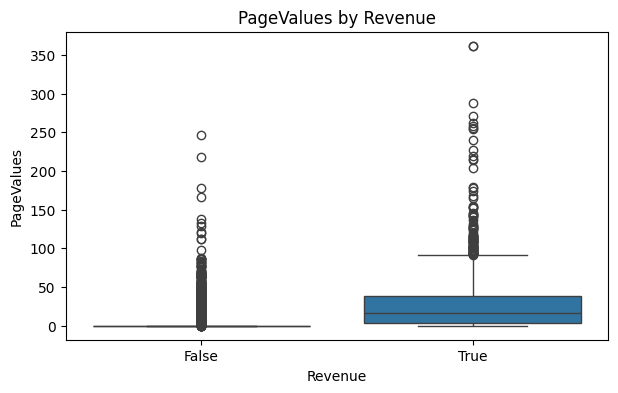

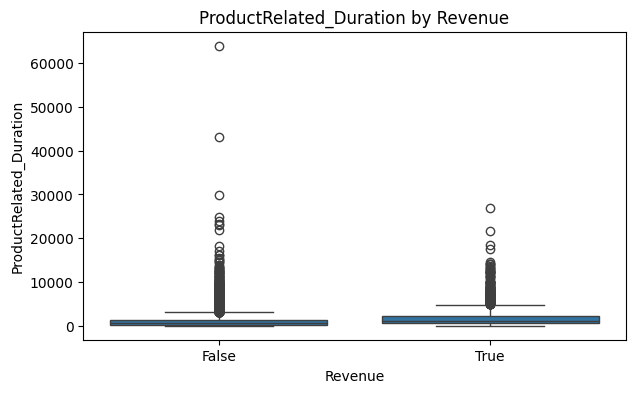

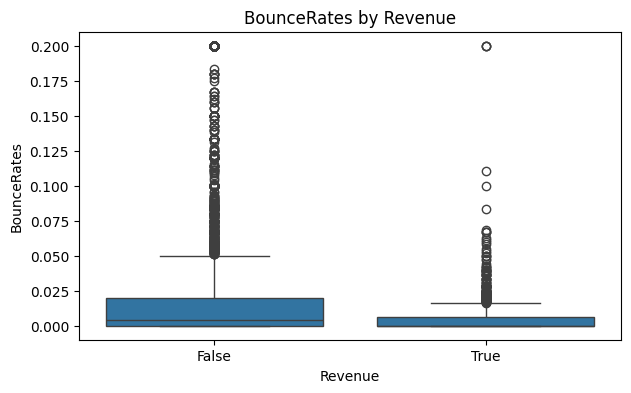

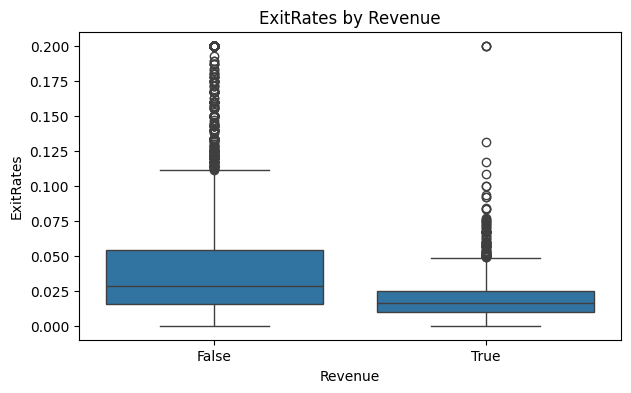

In [23]:
fig_cols = ['PageValues', 'ProductRelated_Duration', 'BounceRates', 'ExitRates']

for col in fig_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x='Revenue', y=col)
    plt.title(f"{col} by Revenue")
    plt.show()

### Box plots of selected behavioral variables by revenue:
- PageValues
  - Shows the clearest separation between buyers and non-buyers.
- ProductRelated_Duration
  - Buyers generally spend longer on product-related pages, though overlap remains.
  - Distribution is strongly right-skewed with many outliers.
- BounceRates and ExitRates
  - Buyers tend to have lower values on both.
  - These appear inversely related to purchase behavior.

##### Pre-processing decisions:
  - Keep these variables in the model.
  - Keeping outliers, since they reflect real browsing behavior.
  - Potential transformation for heavily skewed variables such as `PageValues` and `ProductRelated_Duration`.

In [24]:
num_cols = df.select_dtypes(include=['number']).columns

skewness = df[num_cols].skew().sort_values(ascending=False)
zero_pct = (df[num_cols] == 0).mean().sort_values(ascending=False) * 100

print("Skewness")
print(skewness.round(2))

print("\nPercent Zeros")
print(zero_pct.round(2))

Skewness
Informational_Duration     7.58
ProductRelated_Duration    7.26
PageValues                 6.38
Administrative_Duration    5.62
ProductRelated             4.34
Informational              4.04
SpecialDay                 3.30
Browser                    3.24
BounceRates                2.95
ExitRates                  2.15
OperatingSystems           2.07
TrafficType                1.96
Administrative             1.96
Region                     0.98
dtype: float64

Percent Zeros
SpecialDay                 89.85
Informational_Duration     80.49
Informational              78.66
PageValues                 77.86
Administrative_Duration    47.88
Administrative             46.78
BounceRates                44.75
ProductRelated_Duration     6.12
ExitRates                   0.62
ProductRelated              0.31
OperatingSystems            0.00
Browser                     0.00
Region                      0.00
TrafficType                 0.00
dtype: float64


### Skewness and percent zeros
- Distribution shape
  - Several behavioral variables are strongly right-skewed, especially durations and `PageValues`.
- Zero inflation
  - `SpecialDay`, `Informational`, `Informational_Duration`, and `PageValues` contain many zeros.
  - These zeros likely represent real absence of activity, so they should be preserved.
##### Pre-processing decisions:
- Considering `log1p()` for heavily skewed continuous variables if using linear models.
- `Browser`, `OperatingSystems`, `TrafficType`, and `Region` should be treated as categorical codes rather than continuous numeric variables.

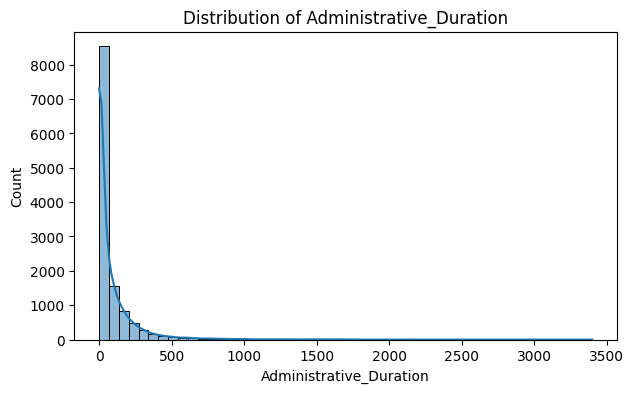

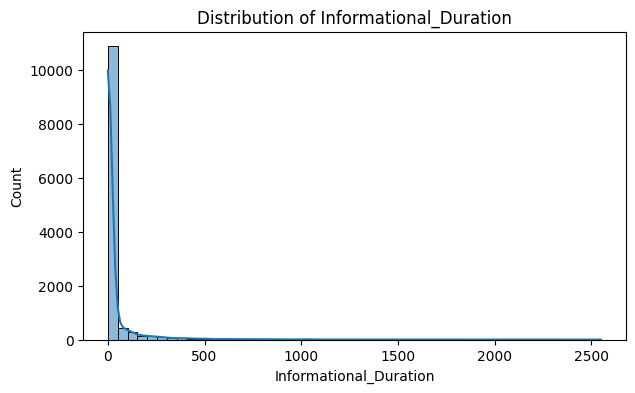

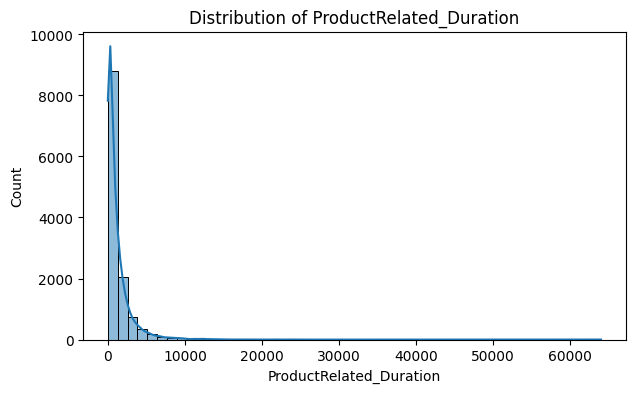

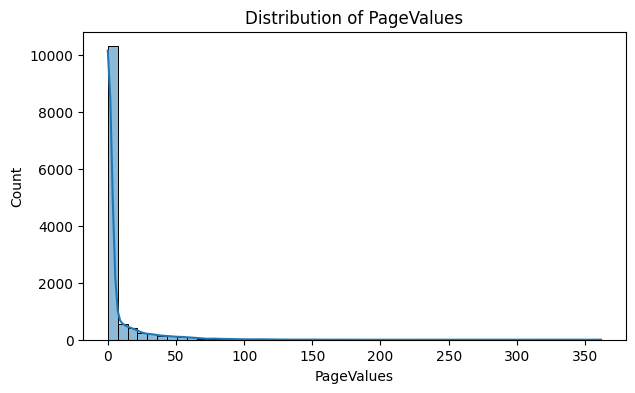

In [26]:
dist_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'PageValues']

for col in dist_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

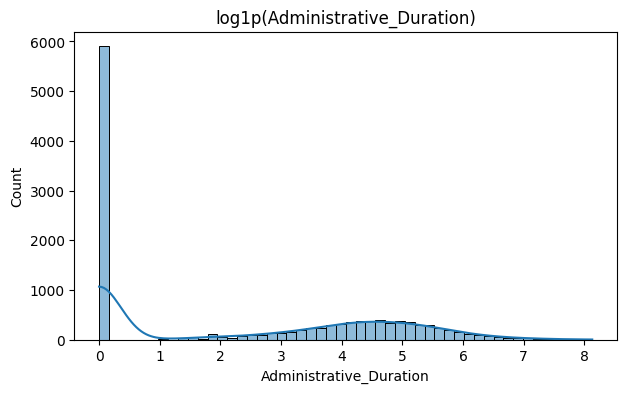

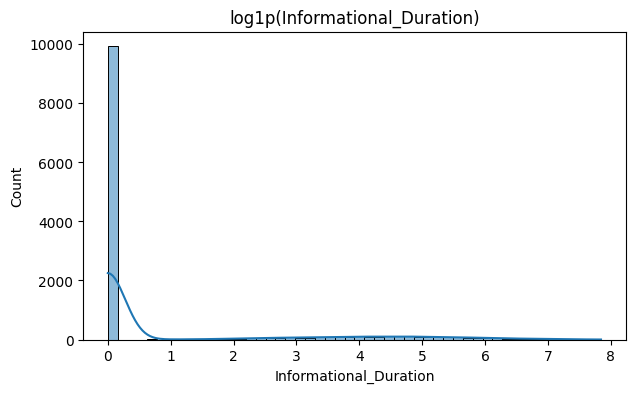

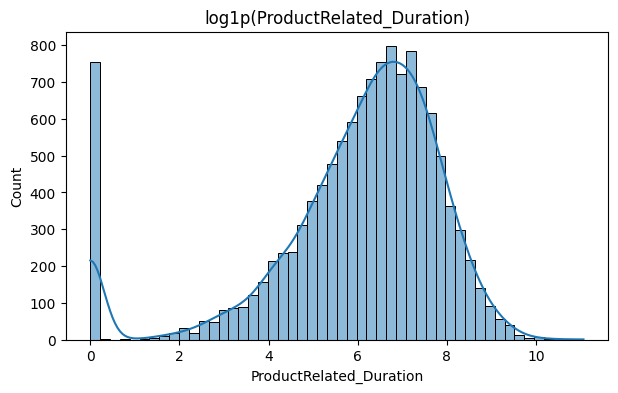

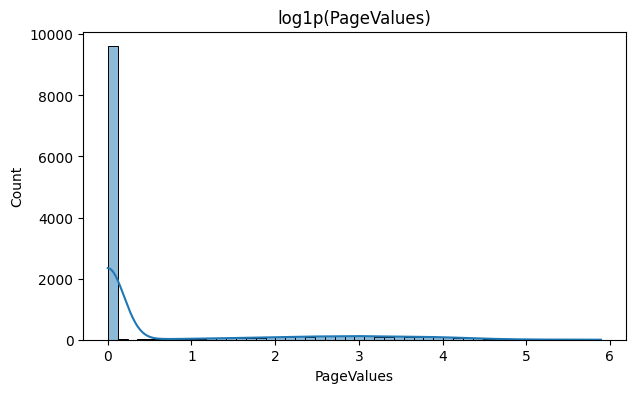

In [27]:
for col in dist_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(np.log1p(df[col]), bins=50, kde=True)
    plt.title(f"log1p({col})")
    plt.show()

### Raw vs log-transformed distributions:
- Raw vs transformed shape
  - The raw duration variables and `PageValues` are heavily compressed near 0 with long right tails.
  - After `log1p()`, the non-zero portion becomes much easier to inspect.

- Transformation insight
  - `ProductRelated_Duration` improves the most after transformation.
  - `Administrative_Duration`, `Informational_Duration`, and `PageValues` still retain a large spike at 0.

##### Pre-processing decisions:
- `log1p()` is a reasonable option for these variables, especially in linear models.
- Zeros should be kept as valid values.
- A separate binary indicator for any activity may be worth testing later for variables with many zeros.


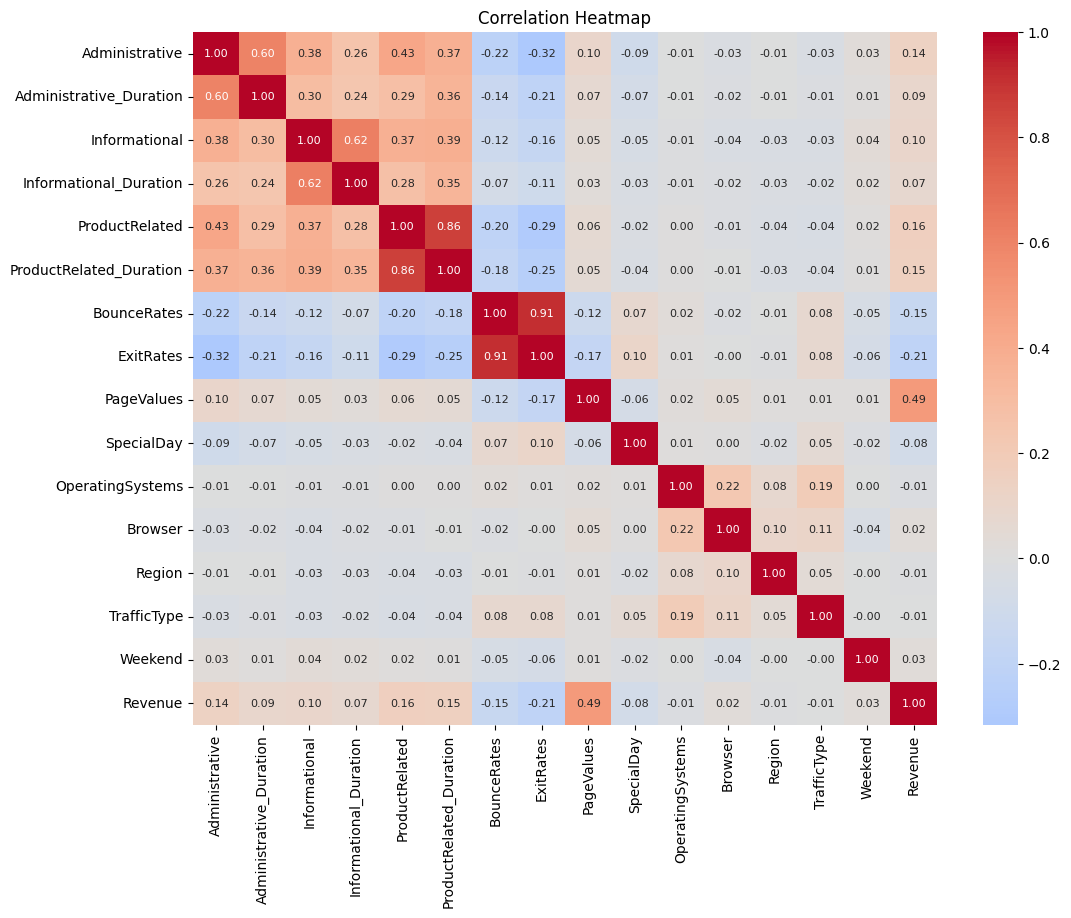

Revenue                    1.000
PageValues                 0.493
ProductRelated             0.159
ProductRelated_Duration    0.152
Administrative             0.139
Informational              0.095
Administrative_Duration    0.094
Informational_Duration     0.070
Weekend                    0.029
Browser                    0.024
TrafficType               -0.005
Region                    -0.012
OperatingSystems          -0.015
SpecialDay                -0.082
BounceRates               -0.151
ExitRates                 -0.207
Name: Revenue, dtype: float64


In [31]:
corr_df = df.copy()
corr_df['Revenue'] = corr_df['Revenue'].astype(int)
corr_df['Weekend'] = corr_df['Weekend'].astype(int)

corr = corr_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,9))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.show()

print(corr['Revenue'].sort_values(ascending=False).round(3))

### Correlation heatmap
- Strongest linear signal to `Revenue`
  - `PageValues` has the strongest positive linear relationship with `Revenue`.
  - `ExitRates` and `BounceRates` show the clearest negative relationships.

- Predictor overlap
  - Page-count and duration pairs are closely related.
  - `BounceRates` and `ExitRates` also appear to carry overlapping information.

##### Pre-processing decisions
- Watch for multicollinearity in linear models.
- For tree-based models, this overlap is less concerning.
- Coded numeric variables should still be treated as categorical rather than interpreted through correlation strength.

---

# Pre-processing

---

# Models

---